In [174]:
import matplotlib
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('S&P 500 Stock Prices 2014-2017.csv')
df['date'] = pd.to_datetime(df['date'])
df.head()


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [175]:
df.describe()

,date,open,high,low,close,volume
count,497472,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,2016-01-06 17:16:00.439984,86.352275,87.132562,85.552467,86.369082,4.253611e+06
min,2014-01-02 00:00:00,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,2015-01-08 00:00:00,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,2016-01-11 00:00:00,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,2017-01-06 00:00:00,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2017-12-29 00:00:00,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08
std,NaN,101.471228,102.312062,100.570957,101.472407,8.232139e+06


In [176]:
df.isna().sum()
df.dropna(inplace=True)

#### Which date in the sample saw the largest overall trading volume? On that date, which two stocks were traded most?

In [177]:
grouped_df = df.groupby('date')

In [178]:
grouped_df['volume'].sum().idxmax()

Timestamp('2015-08-24 00:00:00')

#### so 2015-08-24 had the highest volume of trade

In [179]:
max_date_df = df.loc[df['date'] == '2015-08-24']

In [180]:
max_date_df.sort_values(by= ['volume'], ascending= False)[0:2]

,symbol,date,open,high,low,close,volume
201266,BAC,2015-08-24,15.02,15.98,14.6,15.29,214649482
201209,AAPL,2015-08-24,94.87,108.80,92.0,103.12,162206292


#### so on Date '2015-08-24' companies with symbol 'BAC' and 'AAPL' are the two highest traded by volume

#### Q2: On which day of the week does volume tend to be highest? Lowest?

In [181]:
df['week'] = df['date'].apply(lambda x: x.week)

In [182]:
df['Day'] = df['date'].dt.day_name()

In [183]:
df['year'] = df['date'].dt.year

In [184]:
df_groupby_days = df.groupby('Day')['volume'].sum()

In [185]:
df_groupby_days.reset_index().sort_values(by='volume', ascending=False)

,Day,volume
4,Wednesday,441712704743
0,Friday,440530701666
2,Thursday,431160024905
3,Tuesday,428297070603
1,Monday,374346703519


#### so highest volume traded in a day of the week is WEDNESDAY
as the mark

#### Q3: On which date did Amazon (AMZN) see the most volatility, measured by the difference between the high and low price?

In [186]:
df['volatility'] = df['high'] - df['low']

In [187]:
df_amz = df[df['symbol'] == 'AMZN']
df_amz = df_amz.set_index('date')

In [188]:
df_amz['volatility'].idxmax()

Timestamp('2017-06-09 00:00:00')

#### so amazon saw the highest volatility on 2017-06-09

#### Vizualizing monthly volume and volatility data

In [189]:
df['month'] = df['date'].apply(lambda x: x.month)

In [190]:
df_year = df.groupby('year')['volume'].sum()

df_year_volatility = df.groupby('year')['volatility'].sum()

Text(0.5, 1.0, 'VOLUME TRADED PER YEAR')

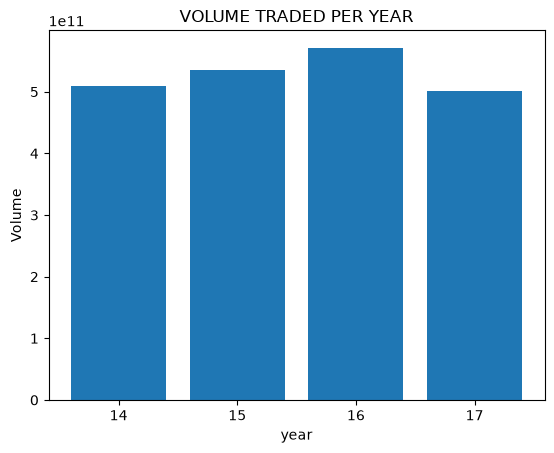

In [191]:
# for yearly basis
months = range(14,18) 
plt.bar(months, df_year)
plt.xticks(months)
plt.ylabel('Volume')
plt.xlabel('year')
plt.title("VOLUME TRADED PER YEAR")

Text(0.5, 1.0, 'VOLATILTIY PER YEAR')

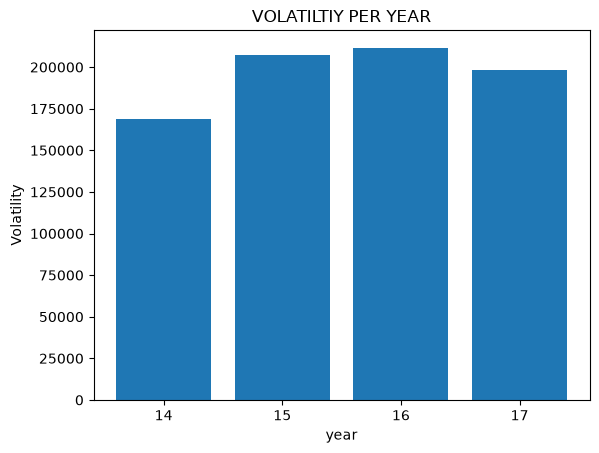

In [192]:
year = range(14,18) 
plt.bar(year, df_year_volatility)
plt.xticks(year)
plt.ylabel('Volatility')
plt.xlabel('year')
plt.title("VOLATILTIY PER YEAR")

#### Company wise volatitlity and volume visualization(top 5 companies by volume and volatitlity)

In [193]:
df_grouped_company = df.groupby('symbol')['volume'].sum()
new_df_companies = df_grouped_company.reset_index().sort_values(by= 'volume',ascending = False)

In [194]:
new_df_companies['Percent'] = (new_df_companies['volume'] / new_df_companies['volume'].sum())* 100
new_df_companies = new_df_companies.head(5)


Text(0.5, 1.0, 'VOLUME TRADED BY TOP 5 COMPANIES')

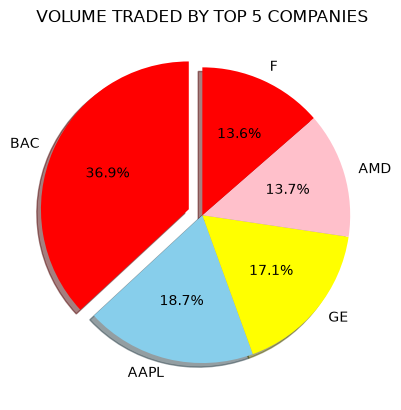

In [195]:
companies = [company for company in new_df_companies['symbol']]
colors = ['red','skyblue','yellow','pink']
plt.pie(new_df_companies['Percent'], labels=companies , autopct='%1.1f%%', colors = colors,explode=[0.1,0,0,0,0], shadow= True, startangle=90)


plt.title('VOLUME TRADED BY TOP 5 COMPANIES')



In [196]:
#volatitlity by companies 
df_grouped_company_vol = df.groupby('symbol')['volatility'].sum()
new_df_companies_vol = df_grouped_company_vol.reset_index().sort_values(by= 'volatility',ascending = False).head(5)

In [197]:
new_df_companies_vol

,symbol,volatility
360,PCLN,24933.5144
393,REGN,12379.5893
207,GOOGL,11513.2282
58,AZO,11431.0913
38,AMZN,11340.0505


Text(0.5, 1.0, 'TOP COMPANIES BY VOLATILITY')

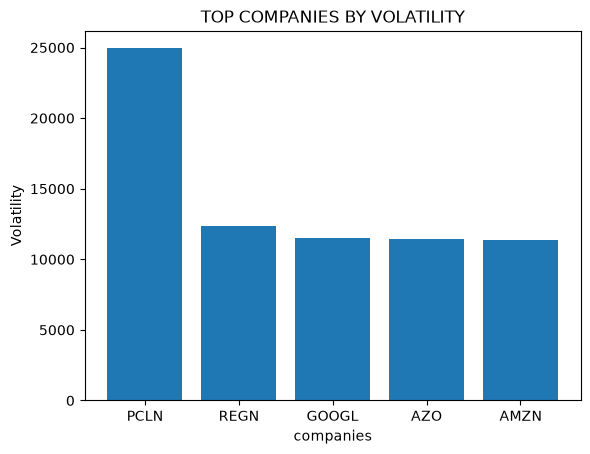

In [198]:
companies = [company for company in new_df_companies_vol['symbol']] 
plt.bar(companies, new_df_companies_vol['volatility'].head(5))
plt.ylabel('Volatility')
plt.xlabel('companies')
plt.title("TOP COMPANIES BY VOLATILITY")

In [199]:
#Monthly top companies by volume in year 2014

In [200]:
df_2014 = df[df['year'] == 2014]

In [201]:
df_groupeby_month_14 = df_2014.groupby('month')['volume'].sum()

Text(0.5, 1.0, 'VOLUME TRADED PER MONTH IN 2014')

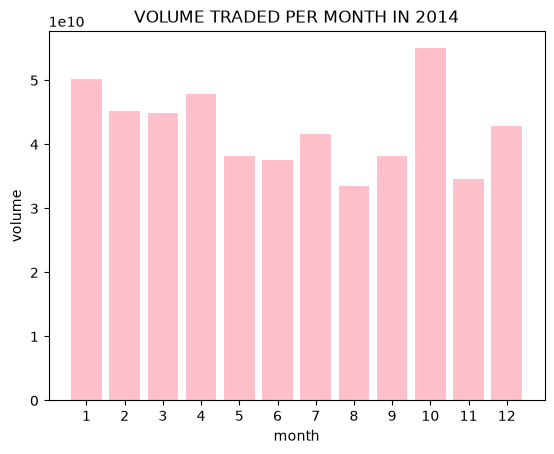

In [202]:
month = range(1,13)
plt.bar(month,df_groupeby_month_14, color='pink')
plt.xticks(month)
plt.ylabel('volume')
plt.xlabel('month')
plt.title("VOLUME TRADED PER MONTH IN 2014")

In [203]:
#for 2015
df_2015 = df[df['year'] == 2015]

In [204]:
df_groupeby_month_15 = df_2015.groupby('month')['volume'].sum()

Text(0.5, 1.0, 'VOLUME TRADED PER MONTH IN 2015')

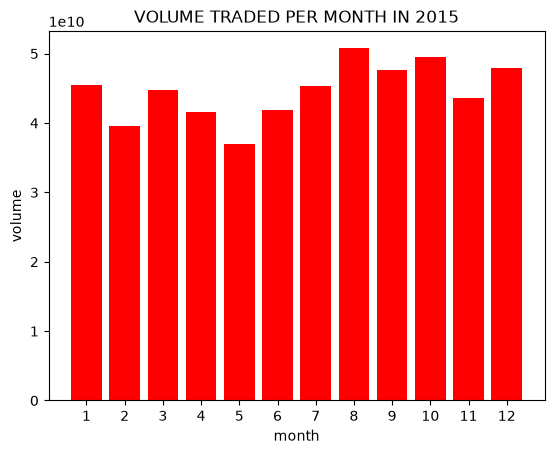

In [205]:
month = range(1,13)
plt.bar(month,df_groupeby_month_15, color='red')
plt.xticks(month)
plt.ylabel('volume')
plt.xlabel('month')
plt.title("VOLUME TRADED PER MONTH IN 2015")

In [206]:
# for 2016
df_2016 = df[df['year'] == 2016]

In [207]:
df_groupeby_month_16 = df_2016.groupby('month')['volume'].sum()

Text(0.5, 1.0, 'VOLUME TRADED PER MONTH IN 2016')

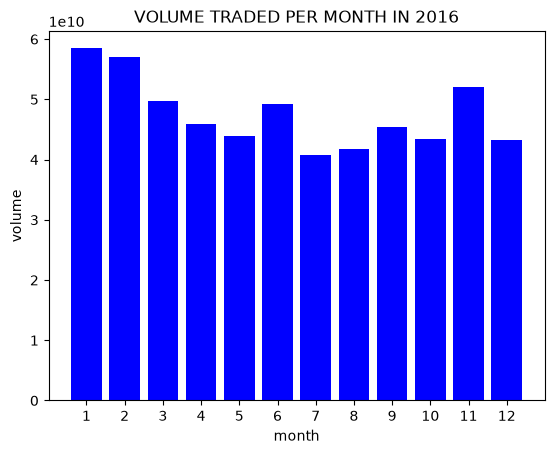

In [208]:
month = range(1,13)
plt.bar(month,df_groupeby_month_16, color='blue')
plt.xticks(month)
plt.ylabel('volume')
plt.xlabel('month')
plt.title("VOLUME TRADED PER MONTH IN 2016")

In [209]:
# for 2017
df_2017 = df[df['year'] == 2017]

In [210]:
df_groupeby_month_17 = df_2017.groupby('month')['volume'].sum()

Text(0.5, 1.0, 'VOLUME TRADED PER MONTH IN 2017')

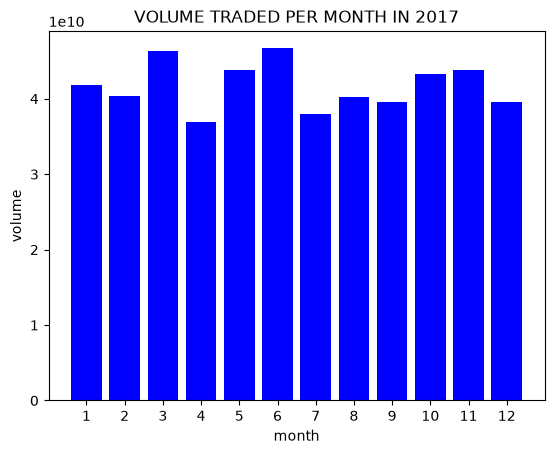

In [211]:
month = range(1,13)
plt.bar(month,df_groupeby_month_17, color='blue')
plt.xticks(month)
plt.ylabel('volume')
plt.xlabel('month')
plt.title("VOLUME TRADED PER MONTH IN 2017")

#### Q4: If you could go back in time and invest in one stock from 1/2/2014 - 12/29/2017, which would you choose? What % gain would you realize?

In [212]:
start_df = df[df['date'] == '2014-01-02'][['symbol', 'open']].rename(columns={'open': 'open_2014'})
end_df = df[df['date'] == '2017-12-29'][['symbol', 'close']].rename(columns={'close': 'close_2017'})

df_merge = pd.merge(start_df, end_df, on='symbol', how='inner')

df_merge['pct_gain'] = (df_merge['close_2017'] - df_merge['open_2014']) / df_merge['open_2014'] * 100

results = df_merge.sort_values('pct_gain', ascending=False)

results

,symbol,open_2014,close_2017,pct_gain
330,NVDA,15.9200,193.50,1115.452261
51,AVGO,52.8500,256.90,386.092715
146,EA,22.9000,105.06,358.777293
25,ALGN,57.0600,222.19,289.397126
318,NFLX,52.4014,191.96,266.326091
...,...,...,...,...
283,MAT,47.5700,15.38,-67.668699
132,DISCK,83.2200,21.17,-74.561404
131,DISCA,90.2100,22.38,-75.191220
385,RRC,83.1300,17.06,-79.477926


#### So NVIDIA had the highest gain over those 4 year periods hence if i could go back in time i would invest in nvidia and this makes sense as becuase of high usage of gpus in data centers and nvidia beeing the market leader it has the highest percent gain

#### Scatterplot between volume and volatility

<Axes: xlabel='volume', ylabel='volatility'>

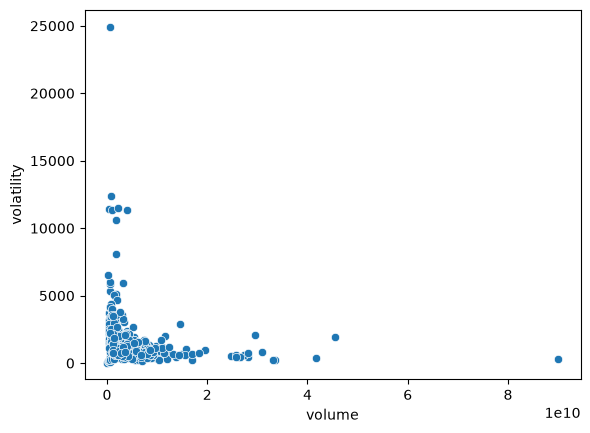

In [215]:
df_companies_voli = df_grouped_company_vol.reset_index().sort_values(by= 'volatility',ascending = False)
merged_stats = pd.merge(df_grouped_company,df_companies_voli, on='symbol')
sns.scatterplot(data=merged_stats, x='volume', y='volatility')

#### Most companies show low volume and low volatility, with a handful of high-volume outliers (like BAC) standing apart from the rest of the S&P 500.